In [1]:
import os
import numpy as np
import pandas as pd
import scipy
import time
import sklearn

import anndata as ad
import scanpy as sc
import tensorflow as tf

In [2]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
from scMTG import scMTG, util

# 1. Data preparation

### 1.1 Load the demo dataset (sub-dataset of [GSE132188](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE132188)).

In [5]:
data_path = './data'
adata = sc.read('%s/%s.h5ad' % (data_path, 'pancreas_demo'))
print(adata)

AnnData object with n_obs × n_vars = 4000 × 3000
    obs: 'time', 'cell_type'


In [6]:
time_field, cell_field = 'time', 'cell_type'
times0 = list(adata.obs[time_field].unique())
print(times0)

[12.5, 13.5, 14.5, 15.5]


In [7]:
adata.obs[time_field].value_counts()

time
12.5    1000
13.5    1000
14.5    1000
15.5    1000
Name: count, dtype: int64

In [8]:
adata.obs[cell_field].value_counts()

cell_type
Mat. Acinar     658
Ductal          492
Tip             445
Prlf. Acinar    370
Ngn3 low EP     339
Endocrine       303
Ngn3 high EP    301
Prlf. Ductal    281
Prlf. Tip       270
Fev+            225
Prlf. Trunk     126
Multipotent     125
Trunk            65
Name: count, dtype: int64

### 1.2 Compute the growth rate.

In [9]:
def score_genes(adata, gene_set_proliferation, gene_set_apoptosis, 
                proliferation_key="proliferation", apoptosis_key="apoptosis"):
    with open(f"data/{gene_set_proliferation}_proliferation.txt") as fin:
        gene_set_proliferation = sorted(tf.strip() for tf in fin.readlines())
    if gene_set_proliferation is not None:
        sc.tl.score_genes(adata, gene_set_proliferation, score_name=proliferation_key)

    with open(f"data/{gene_set_apoptosis}_apoptosis.txt") as fin:
        gene_set_apoptosis = sorted(tf.strip() for tf in fin.readlines())
    if gene_set_apoptosis is not None:
        sc.tl.score_genes(adata, gene_set_apoptosis, score_name=apoptosis_key)

In [10]:
score_genes(adata, gene_set_proliferation='mouse', gene_set_apoptosis='mouse')

In [11]:
proliferation_key = "proliferation"
apoptosis_key = "apoptosis"
growth_rates = []
for i in range(len(times0[:-1])):
    delta_t = times0[i+1]-times0[i]
    growth_rates.append(util.growth_rate(adata[adata.obs[time_field]==times0[i]], delta_t=delta_t))
last_size = len(adata[adata.obs[time_field]==times0[-1]])
growth_rates.append(np.ones(last_size, dtype='float32') / last_size)

# 2. run scMTG

### 2.1 Train scMTG model.

In [12]:
# Do not perform interpolation.
datas = [adata.X[adata.obs[time_field]==item].todense() for item in times0]
for i in range(len(times0)):
    print(i, datas[i].shape, growth_rates[i].shape)

0 (1000, 3000) (1000,)
1 (1000, 3000) (1000,)
2 (1000, 3000) (1000,)
3 (1000, 3000) (1000,)


In [13]:
# Perform interpolation.
interpolate_times = 2
delta_t = float(times0[interpolate_times+1]) - float(times0[interpolate_times-1])
growth_rates[interpolate_times-1] = util.growth_rate(adata[adata.obs[time_field]==times0[interpolate_times-1]], delta_t=delta_t)
for i in range(len(datas)):
    print(i, datas[i].shape, growth_rates[i].shape)
datas.pop(interpolate_times)
growth_rates.pop(interpolate_times)
print(len(datas), len(growth_rates))

0 (1000, 3000) (1000,)
1 (1000, 3000) (1000,)
2 (1000, 3000) (1000,)
3 (1000, 3000) (1000,)
3 3


In [14]:
data_name = 'pancreas'
params = {'dataset': data_name,
 'output_dir': './output',
 'alpha': 10,
 'beta': 5,
 'sd': 0.5,
 'e_dim': adata.shape[1],
 'z_dim': 30,
 'noise_dim': 8,
 'lr': 0.0002,
 'g_d_freq': 3,
 'ae_gan_freq': 5,
 'nb_time': len(datas),
 'e_units': [2048, 1024, 512, 256],
 'd_units': [256, 512, 1024, 2048],
 'gen_units': [64, 128, 128, 64],
 'dis_units': [64, 128, 64],
 'save_model': True,
 'save_res': True}

In [15]:
model = scMTG(params)

2026-06-17 19:02:22.416320: E tensorflow/stream_executor/cuda/cuda_driver.cc:271] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-06-17 19:02:22.416992: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:169] retrieving CUDA diagnostic information for host: n11.openness.cas
2026-06-17 19:02:22.417099: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:176] hostname: n11.openness.cas
2026-06-17 19:02:22.417611: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:200] libcuda reported version is: 595.58.3
2026-06-17 19:02:22.417830: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:204] kernel reported version is: Not found: could not find kernel module information in driver version file contents: "NVRM version: NVIDIA UNIX Open Kernel Module for x86_64  595.58.03  Release Build  (dvs-builder@U22-I3-AM25-28-3)  Tue Mar 17 19:55:10 UTC 2026
GCC version:  gcc version 15.2.0 (Ubuntu 15.2.0-16ubuntu1) 
"
2026-06-17 19:02:22.420259: I tensorflo

Model: "base_fully_connected_net"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 2048)              6146048   
_________________________________________________________________
batch_normalization (BatchNo multiple                  0 (unused)
_________________________________________________________________
dropout (Dropout)            (None, 2048)              0         
_________________________________________________________________
leaky_re_lu (LeakyReLU)      (None, 2048)              0         
_________________________________________________________________
dense_1 (Dense)              (None, 1024)              2098176   
_________________________________________________________________
batch_normalization_1 (Batch multiple                  0 (unused)
_________________________________________________________________
dropout_1 (Dropout)          (None, 1024) 

In [16]:
model.train(data=datas, weights=growth_rates, batch_size=32, n_iter=100000, batches_per_verbose=500)

2026-06-17 19:02:35.350064: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Iteration [0] : loss_t [46.9500], loss_rec [0.8037], loss_gp [4.0977], loss_d [0.3884], loss_g [-0.0278] loss_td [0.9618]
Iteration [500] : loss_t [5.5268], loss_rec [0.4264], loss_gp [0.0064], loss_d [-0.6606], loss_g [0.0882] loss_td [1.1217]
Iteration [1000] : loss_t [6.3888], loss_rec [0.4150], loss_gp [0.0195], loss_d [-1.1111], loss_g [0.0121] loss_td [1.3754]
Iteration [1500] : loss_t [16.0213], loss_rec [0.4039], loss_gp [0.0022], loss_d [-1.3004], loss_g [-0.0070] loss_td [3.3805]
Iteration [2000] : loss_t [34.5710], loss_rec [0.4035], loss_gp [0.0094], loss_d [-1.5706], loss_g [-0.0871] loss_td [7.1463]
Iteration [2500] : loss_t [25.7011], loss_rec [0.3938], loss_gp [0.0152], loss_d [-1.7314], loss_g [-0.1547] loss_td [5.4082]
Iteration [3000] : loss_t [51.6262], loss_rec [0.3879], loss_gp [0.0381], loss_d [-2.2855], loss_g [-0.4891] loss_td [10.7264]
Iteration [3500] : loss_t [38.4093], loss_rec [0.3907], loss_gp [0.0126], loss_d [-2.7030], loss_g [-0.4738] loss_td [8.2140]


Iteration [32500] : loss_t [4.2995], loss_rec [0.3349], loss_gp [0.0145], loss_d [-1.5404], loss_g [-1.1562] loss_td [1.3032]
Iteration [33000] : loss_t [4.2426], loss_rec [0.3432], loss_gp [0.0022], loss_d [-1.3695], loss_g [-1.1160] loss_td [1.2727]
Iteration [33500] : loss_t [4.3681], loss_rec [0.3463], loss_gp [0.0012], loss_d [-1.3693], loss_g [-1.1794] loss_td [1.3117]
Iteration [34000] : loss_t [5.6864], loss_rec [0.3325], loss_gp [0.0077], loss_d [-1.5737], loss_g [-1.1736] loss_td [1.6049]
Iteration [34500] : loss_t [3.7510], loss_rec [0.3375], loss_gp [0.0028], loss_d [-1.5429], loss_g [-1.1142] loss_td [1.2085]
Iteration [35000] : loss_t [3.6073], loss_rec [0.3380], loss_gp [0.0066], loss_d [-1.5192], loss_g [-1.0718] loss_td [1.1589]
Iteration [35500] : loss_t [4.1076], loss_rec [0.3372], loss_gp [0.0099], loss_d [-1.4503], loss_g [-1.0276] loss_td [1.2299]
Iteration [36000] : loss_t [5.4970], loss_rec [0.3413], loss_gp [0.0081], loss_d [-1.4219], loss_g [-0.9617] loss_td [

Iteration [65500] : loss_t [0.8983], loss_rec [0.3280], loss_gp [0.0047], loss_d [-0.7350], loss_g [-0.3449] loss_td [0.3205]
Iteration [66000] : loss_t [0.6913], loss_rec [0.3284], loss_gp [0.0044], loss_d [-0.7332], loss_g [-0.3779] loss_td [0.2860]
Iteration [66500] : loss_t [0.8180], loss_rec [0.3304], loss_gp [0.0081], loss_d [-0.8242], loss_g [-0.3914] loss_td [0.3245]
Iteration [67000] : loss_t [0.7590], loss_rec [0.3264], loss_gp [0.0012], loss_d [-0.7763], loss_g [-0.3195] loss_td [0.3033]
Iteration [67500] : loss_t [0.5376], loss_rec [0.3341], loss_gp [0.0011], loss_d [-0.7086], loss_g [-0.3841] loss_td [0.2570]
Iteration [68000] : loss_t [0.6616], loss_rec [0.3333], loss_gp [0.0028], loss_d [-0.6548], loss_g [-0.3909] loss_td [0.2692]
Iteration [68500] : loss_t [0.7258], loss_rec [0.3289], loss_gp [0.0016], loss_d [-0.7406], loss_g [-0.3455] loss_td [0.2934]
Iteration [69000] : loss_t [0.5192], loss_rec [0.3399], loss_gp [0.0006], loss_d [-0.7620], loss_g [-0.3533] loss_td [

Iteration [98500] : loss_t [0.2197], loss_rec [0.3240], loss_gp [0.0029], loss_d [-0.4718], loss_g [-0.2697] loss_td [0.1216]
Iteration [99000] : loss_t [0.1899], loss_rec [0.3232], loss_gp [0.0016], loss_d [-0.4820], loss_g [-0.2680] loss_td [0.1200]
Iteration [99500] : loss_t [0.3788], loss_rec [0.3311], loss_gp [0.0022], loss_d [-0.4098], loss_g [-0.2511] loss_td [0.1374]
Iteration [100000] : loss_t [0.2945], loss_rec [0.3320], loss_gp [0.0012], loss_d [-0.4900], loss_g [-0.2496] loss_td [0.1380]


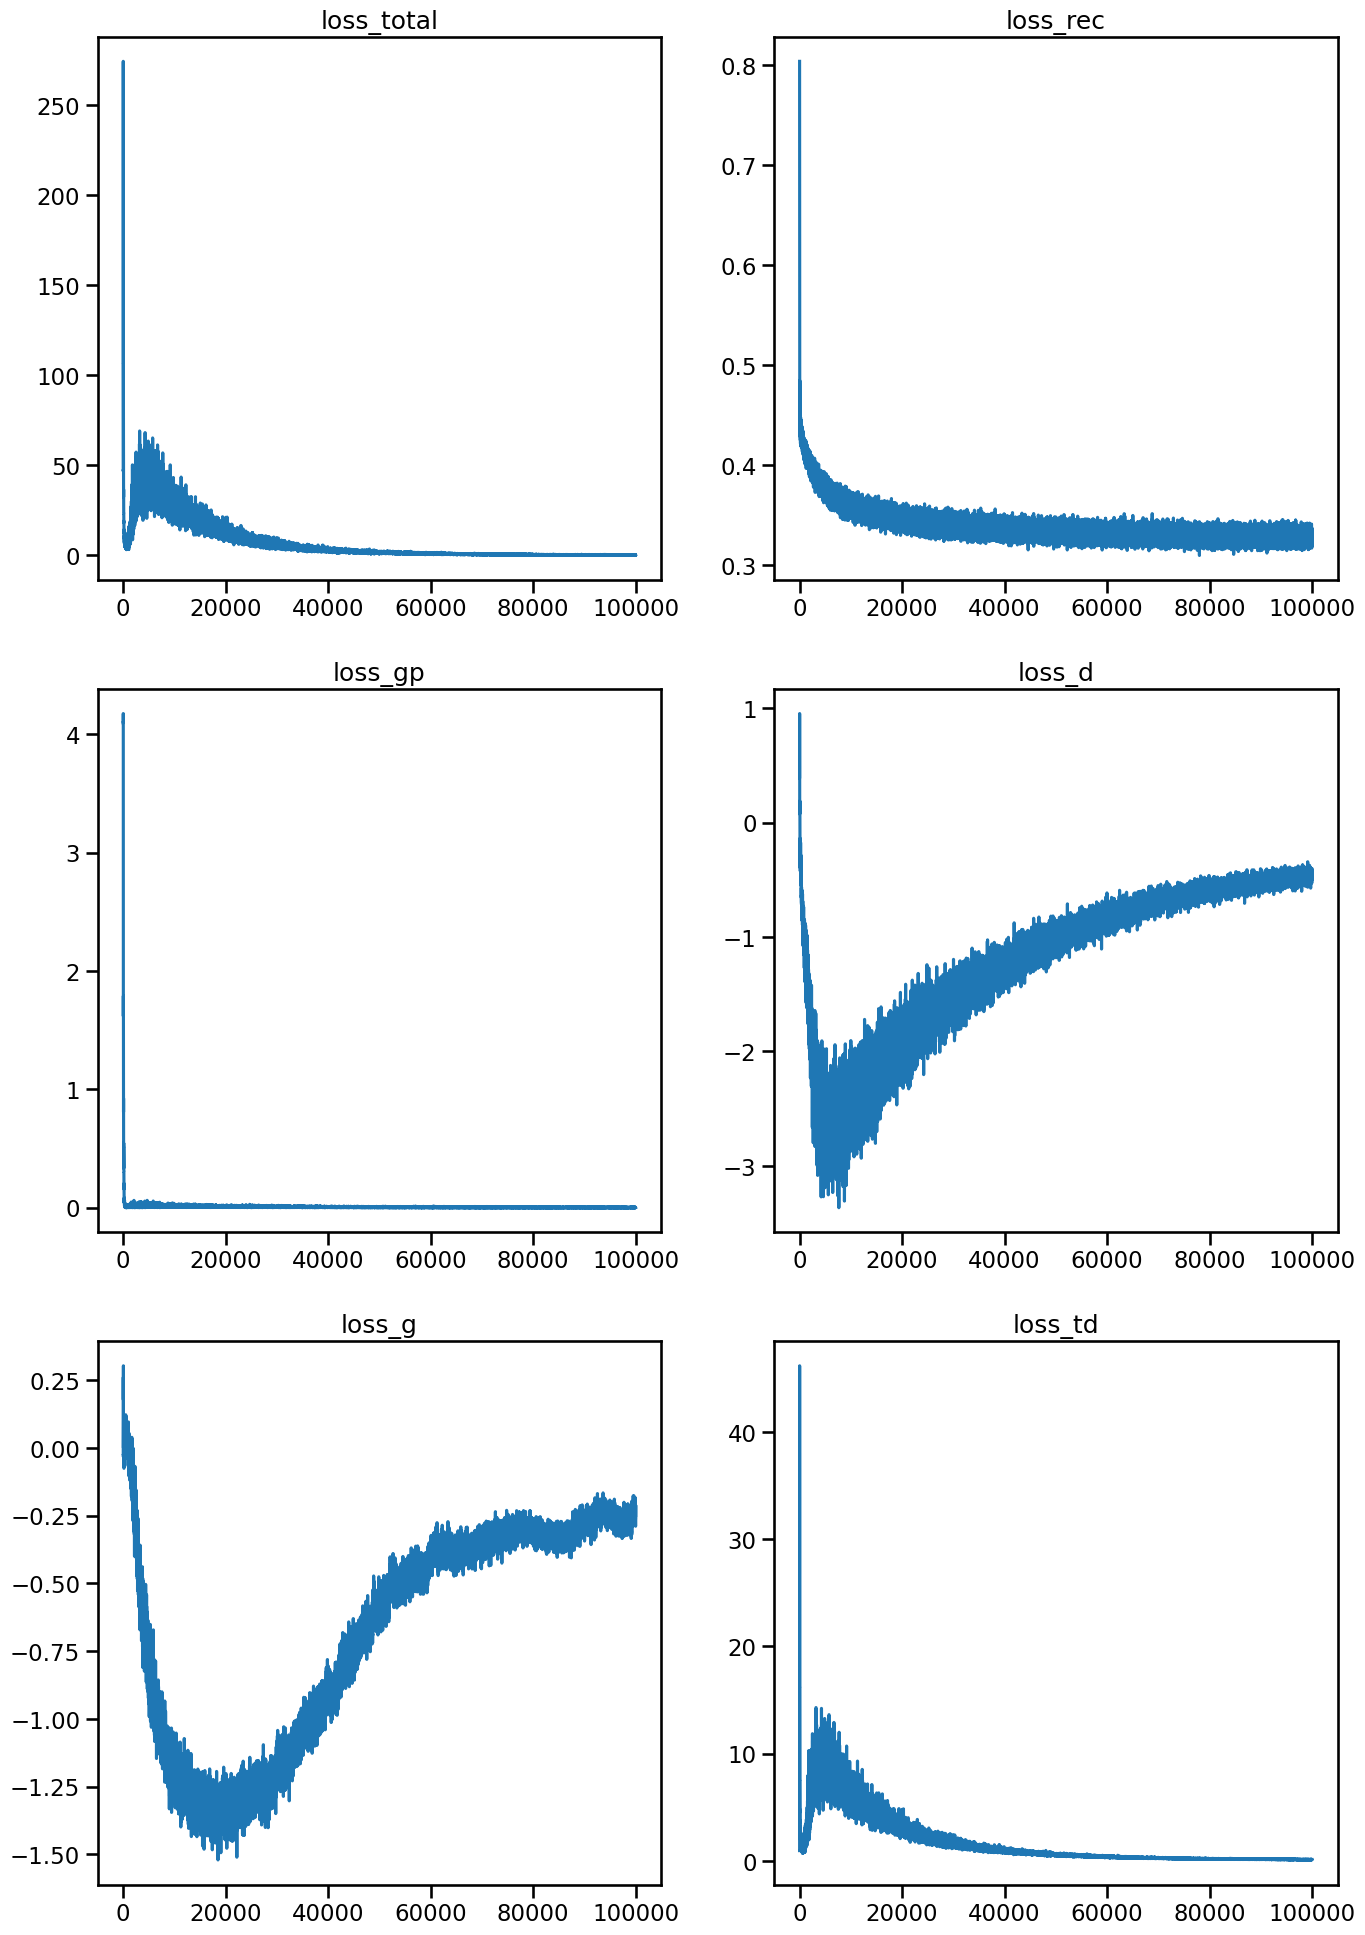

In [17]:
loss_pd = pd.read_csv('./output/%s/loss_pd.csv' % (model.timestamp), sep='\t')
f = plt.figure(figsize=(16, 24))
ax = f.add_subplot(3, 2, 1)
ax.plot(loss_pd['batch_idx'], loss_pd['loss_total'])
ax.set_title('loss_total')

ax = f.add_subplot(3, 2, 2)
ax.plot(loss_pd['batch_idx'], loss_pd['loss_rec'])
ax.set_title('loss_rec')

ax = f.add_subplot(3, 2, 3)
ax.plot(loss_pd['batch_idx'], loss_pd['loss_gp'])
ax.set_title('loss_gp')

ax = f.add_subplot(3, 2, 4)
ax.plot(loss_pd['batch_idx'], loss_pd['loss_d'])
ax.set_title('loss_d')

ax = f.add_subplot(3, 2, 5)
ax.plot(loss_pd['batch_idx'], loss_pd['loss_g'])
ax.set_title('loss_g')

ax = f.add_subplot(3, 2, 6)
ax.plot(loss_pd['batch_idx'], loss_pd['loss_td'])
# plt.ylim(0,10.0)
ax.set_title('loss_td')
plt.show()

### 2.2 Generate transition matrix.

In [19]:
times = 0
trans_mtx = model.compute_trans_mat(times=times)
print(trans_mtx.shape)

(1000, 1000)


In [20]:
# Generate cell-type-specifc transition matrix.
source, target = times0[times], times0[times+1]
print(source, target)

source_labels = adata[adata.obs[time_field]==source].obs[cell_field]
target_labels = adata[adata.obs[time_field]==target].obs[cell_field]
ps = []
for ct1 in list(source_labels.cat.categories):
    p1s = []
    p1 = np.sum(trans_mtx[source_labels==ct1], axis=0)
    for ct2 in list(target_labels.cat.categories):
        p1s.append(np.sum(p1[target_labels==ct2]))
    ps.append(p1s)
ps = np.array(ps)
ps = ps / np.sum(ps, axis=1, keepdims=True)
tm = pd.DataFrame(ps, index=list(source_labels.cat.categories), columns=list(target_labels.cat.categories))
print(tm.shape)

12.5 13.5
(11, 12)


/home/cuixuejian/anaconda3/envs/tf_gpu4/lib/python3.8/site-packages/scanpy/_settings.py:447: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  IPython.display.set_matplotlib_formats(*ipython_format)


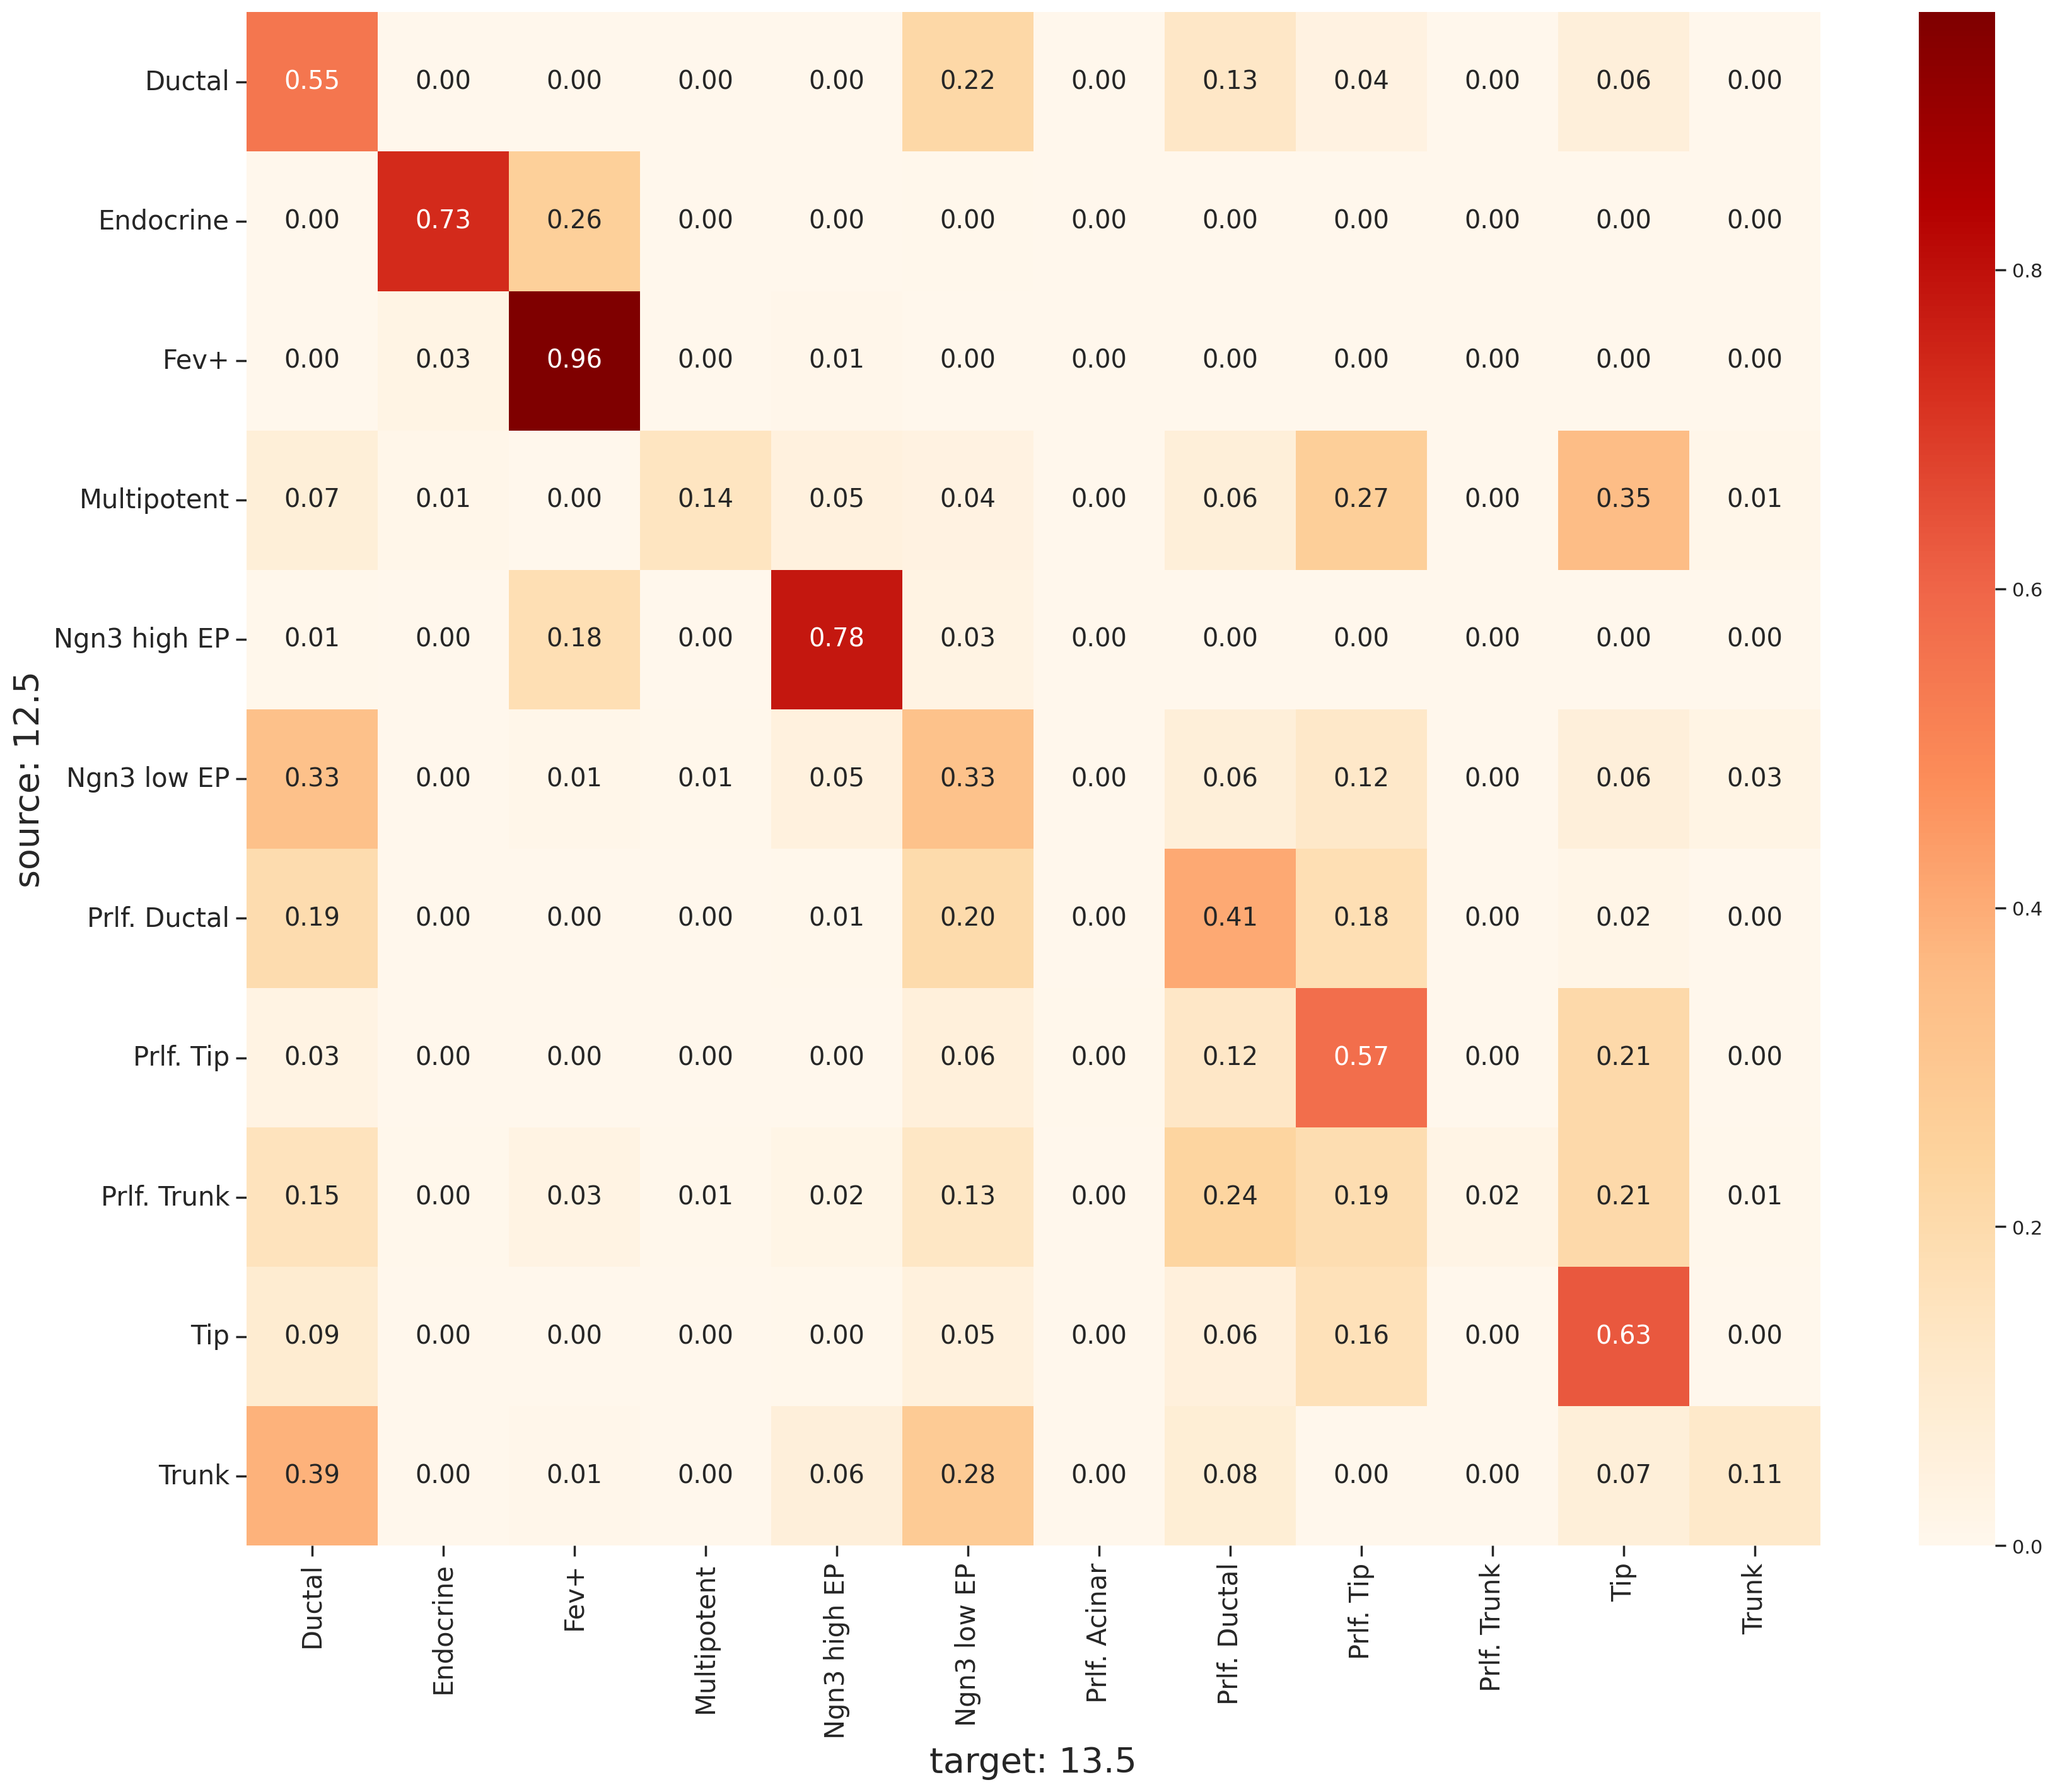

In [21]:
sc.settings.set_figure_params(dpi=100, facecolor='white', figsize=(20,16), frameon=True, fontsize=15)
sns.set_theme(style='ticks')
ax = sns.heatmap(data=tm, annot=True, fmt=".2f", annot_kws=dict(fontsize='large'), cmap='OrRd')
# ax.xaxis.tick_top()
plt.xlabel('target: {}'.format(target), fontsize=20);plt.ylabel('source: {}'.format(source), fontsize=20)
plt.xticks(rotation=90, fontsize=15);plt.yticks(rotation=0, fontsize=15)
plt.show()

### 2.3 Evaluate the performance of interpolation.

In [22]:
interpolate_times = 2
real_data = np.array(adata.X[adata.obs[time_field]==times0[interpolate_times]].todense())
print(real_data.shape)

(1000, 3000)


In [23]:
trans_mtx_inter = model.compute_trans_mat(times=interpolate_times-1)
print(trans_mtx_inter.shape)

(1000, 1000)


In [25]:
interp_size = real_data.shape[0]
t0, t05, t1 = times0[interpolate_times-1], times0[interpolate_times], times0[interpolate_times+1]
print(t0, t05, t1)
interp_frac = (float(t05) - float(t0)) / (float(t1) - float(t0))
print(interp_frac)

data_series = model.data_sampler.load_all()
embed_series = [model.encoder.predict(item) for item in data_series]
gen_data_latent = util.interpolate(embed_series[interpolate_times-1], embed_series[interpolate_times], 
                                   trans_mtx_inter, interp_frac, interp_size)
print(gen_data_latent.shape)
gen_data = model.decoder.predict(gen_data_latent)[-1]
print(gen_data.shape)

13.5 14.5 15.5
0.5
(1000, 30)
(1000, 3000)


In [27]:
mmd_value, pearson_corr, spearman_corr, _ = util.cal_metrics(gen_data, real_data)
print('MMD = %.3f\nPCC = %.3f\nSCC = %.3f'%(mmd_value, pearson_corr, spearman_corr))

MMD = 31.470
PCC = 0.971
SCC = 0.976


In [28]:
import scib
adata_gen = ad.AnnData(np.concatenate((gen_data, real_data), axis=0))
adata_gen.obs['batch'] = pd.Categorical(['gen']*len(gen_data) + ['true']*len(real_data))
print('LISI = %.3f'%(scib.me.ilisi_graph(adata_gen, batch_key="batch", type_="full")))

Chunk 7 does not have enough neighbors. Skipping...
Chunk 41 does not have enough neighbors. Skipping...
Chunk 82 does not have enough neighbors. Skipping...
Chunk 90 does not have enough neighbors. Skipping...
Chunk 92 does not have enough neighbors. Skipping...
Chunk 106 does not have enough neighbors. Skipping...
Chunk 163 does not have enough neighbors. Skipping...
Chunk 172 does not have enough neighbors. Skipping...
Chunk 201 does not have enough neighbors. Skipping...
Chunk 273 does not have enough neighbors. Skipping...
Chunk 328 does not have enough neighbors. Skipping...
Chunk 342 does not have enough neighbors. Skipping...
Chunk 360 does not have enough neighbors. Skipping...
Chunk 380 does not have enough neighbors. Skipping...
Chunk 383 does not have enough neighbors. Skipping...
Chunk 445 does not have enough neighbors. Skipping...
Chunk 451 does not have enough neighbors. Skipping...
Chunk 452 does not have enough neighbors. Skipping...
Chunk 454 does not have enough nei

In [29]:
adata_gen.obs['cell_type'] = 'gen'
adata_gen.obs['cell_type'][adata_gen.obs['batch']=='true'] = adata.obs[cell_field].values[adata.obs[time_field] == t05].copy()

/tmp/ipykernel_1523192/3872164242.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_gen.obs['cell_type'][adata_gen.obs['batch']=='true'] = adata.obs[cell_field].values[adata.obs[time_field] == t05].copy()


/home/cuixuejian/anaconda3/envs/tf_gpu4/lib/python3.8/site-packages/scanpy/_settings.py:447: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  IPython.display.set_matplotlib_formats(*ipython_format)
/home/cuixuejian/anaconda3/envs/tf_gpu4/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:163: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy(get_cmap(cmap))
/home/cuixuejian/anaconda3/envs/tf_gpu4/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/cuixuejian/anaconda3/envs/tf_gpu4/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWar

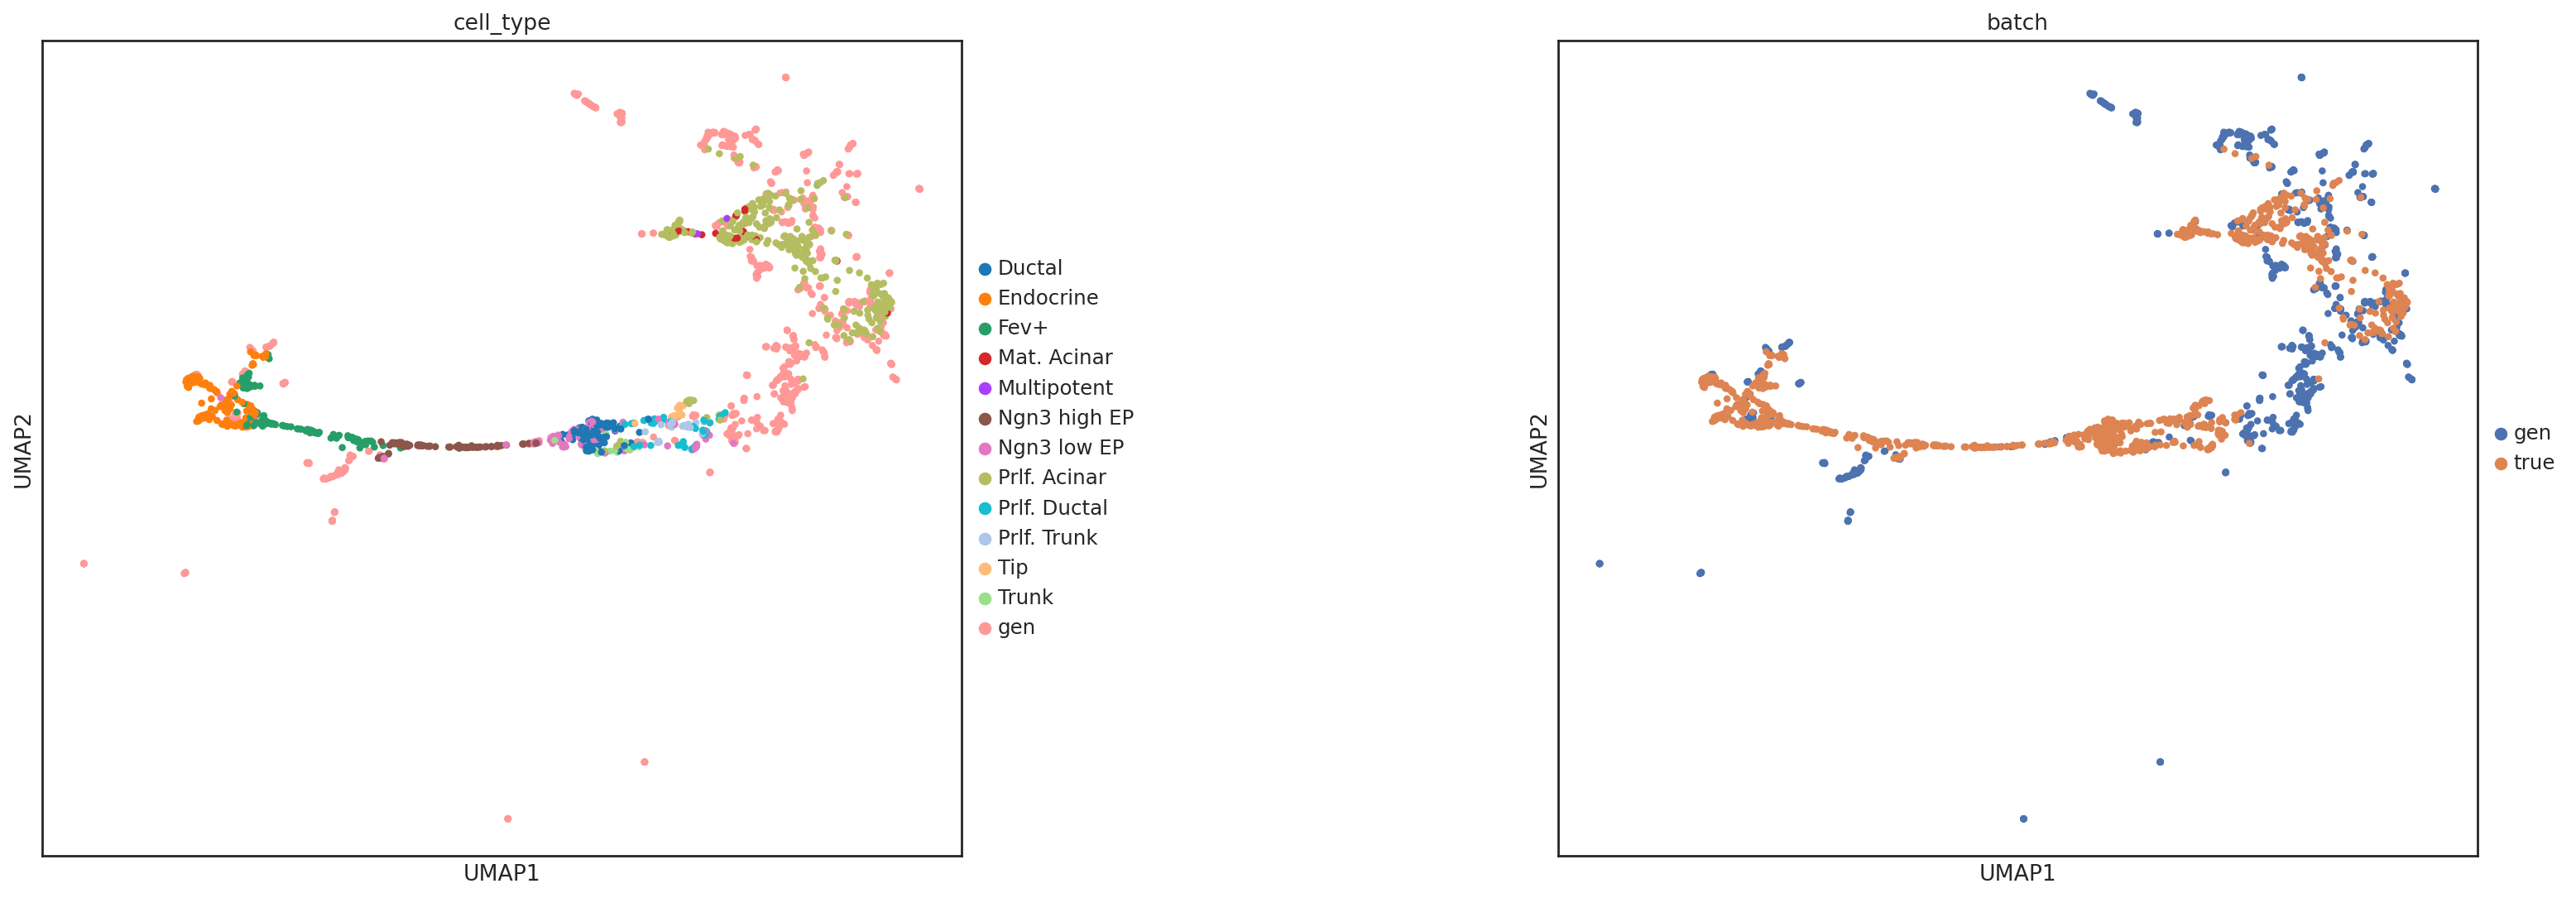

In [30]:
sc.settings.set_figure_params(dpi=80,facecolor='white',figsize=(8,8),frameon=True,fontsize=20)
sns.set_theme(style='ticks')
sc.pp.neighbors(adata_gen, n_neighbors=15, method='umap', metric='correlation', use_rep='X_pca', random_state=0)
sc.tl.umap(adata_gen, min_dist=0.1)
sc.pl.umap(adata_gen, color=['cell_type', 'batch'], wspace=0.5)